#SOAP

In [1]:
# Optimizador SOAP
import torch
import torch.nn as nn
import torch.optim as optim

from itertools import chain

# Parts of the code are modifications of Pytorch's AdamW optimizer
# Parts of the code are modifications of code from https://github.com/jiaweizzhao/GaLore/blob/master/galore_torch/galore_projector.py
# CÓDIGO DE https://github.com/nikhilvyas/SOAP/blob/main/soap.py
# USO INSPIRADO POR PAPER https://arxiv.org/pdf/2602.19265
class SOAP(optim.Optimizer):
    """
    Implements SOAP algorithm (https://arxiv.org/abs/2409.11321).

    Parameters:
        params (`Iterable[nn.parameter.Parameter]`):
            Iterable of parameters to optimize or dictionaries defining parameter groups.
        lr (`float`, *optional*, defaults to 0.003):
            The learning rate to use.
        betas (`Tuple[float,float]`, *optional*, defaults to `(0.95, 0.95)`):
            Adam's betas parameters (b1, b2).
        shampoo_beta (`float`, *optional*, defaults to -1):
            If >= 0, use this beta for the preconditioner (L and R in paper, state['GG'] below) moving average instead of betas[1].
        eps (`float`, *optional*, defaults to 1e-08):
            Adam's epsilon for numerical stability.
        weight_decay (`float`, *optional*, defaults to 0.01): weight decay coefficient.
        precondition_frequency (`int`, *optional*, defaults to 10):
            How often to update the preconditioner.
        max_precond_dim (`int`, *optional*, defaults to 10000):
            Maximum dimension of the preconditioner.
            Set to 10000, so that we exclude most common vocab sizes while including layers.
        merge_dims (`bool`, *optional*, defaults to `False`):
            Whether or not to merge dimensions of the preconditioner.
        precondition_1d (`bool`, *optional*, defaults to `False`):
            Whether or not to precondition 1D gradients.
        normalize_grads (`bool`, *optional*, defaults to `False`):
            Whether or not to normalize gradients per layer.
            Helps at large precondition_frequency (~100 in our experiments),
            but hurts performance at small precondition_frequency (~10 in our experiments).
        data_format (`str`, *optional*, defaults to `channels_first`):
            Data format of the input for convolutional layers.
            Should be "channels_last" for data_format of NHWC and "channels_first" for NCHW.
        correct_bias (`bool`, *optional*, defaults to `True`):
            Whether or not to use bias correction in Adam.
    """

    def __init__(
        self,
        params,
        lr: float = 3e-3,
        betas=(0.95, 0.95),
        shampoo_beta: float= -1,
        eps: float = 1e-8,
        weight_decay: float = 0.01,
        precondition_frequency: int=10,
        max_precond_dim: int=10000, #
        merge_dims: bool = False, # Merge dimensions till the product of the dimensions is less than or equal to max_precond_dim.
        precondition_1d: bool = False,
        normalize_grads: bool = False,
        data_format: str = "channels_first",
        correct_bias: bool = True,
    ):
        defaults = {
            "lr": lr,
            "betas": betas,
            "shampoo_beta": shampoo_beta,
            "eps": eps,
            "weight_decay": weight_decay,
            "precondition_frequency": precondition_frequency,
            "max_precond_dim": max_precond_dim,
            "merge_dims": merge_dims,
            "precondition_1d": precondition_1d,
            "normalize_grads": normalize_grads,
            "correct_bias": correct_bias,
        }
        super().__init__(params, defaults)
        self._data_format = data_format

    def merge_dims(self, grad, max_precond_dim):
        """
        Merges dimensions of the gradient tensor till the product of the dimensions is less than or equal to max_precond_dim.
        """
        assert self._data_format in ["channels_first", "channels_last"]
        if self._data_format == "channels_last" and grad.dim() == 4:
            grad = grad.permute(0, 3, 1, 2)
        shape = grad.shape
        new_shape = []

        curr_shape = 1
        for sh in shape:
            temp_shape = curr_shape * sh
            if temp_shape > max_precond_dim:
                if curr_shape > 1:
                    new_shape.append(curr_shape)
                    curr_shape = sh
                else:
                    new_shape.append(sh)
                    curr_shape = 1
            else:
                curr_shape = temp_shape

        if curr_shape > 1 or len(new_shape)==0:
            new_shape.append(curr_shape)

        new_grad = grad.reshape(new_shape)
        return new_grad

    @torch.no_grad()
    def step(self, closure = None):
        """
        Performs a single optimization step.

        Arguments:
            closure (`Callable`, *optional*): A closure that reevaluates the model and returns the loss.
        """
        if closure is None:
            loss = None
        else:
            loss = closure()

        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad

                state = self.state[p]

                if "step" not in state:
                    state["step"] = 0

                # State initialization
                if "exp_avg" not in state:
                    # Exponential moving average of gradient values
                    state["exp_avg"] = torch.zeros_like(grad)
                    # Exponential moving average of squared gradient values
                    state["exp_avg_sq"] = torch.zeros_like(grad)

                if 'Q' not in state:
                    self.init_preconditioner(
                        grad,
                        state,
                        precondition_frequency=group['precondition_frequency'],
                        precondition_1d=group['precondition_1d'],
                        shampoo_beta=(group['shampoo_beta'] if group['shampoo_beta'] >= 0 else group["betas"][1]),
                        max_precond_dim=group['max_precond_dim'],
                        merge_dims=group["merge_dims"],
                    )
                    self.update_preconditioner(grad, state,
                                               max_precond_dim=group['max_precond_dim'],
                                               merge_dims=group["merge_dims"],
                                               precondition_1d=group["precondition_1d"])
                    continue # first step is skipped so that we never use the current gradients in the projection.

                # Projecting gradients to the eigenbases of Shampoo's preconditioner
                # i.e. projecting to the eigenbases of matrices in state['GG']
                grad_projected = self.project(grad, state, merge_dims=group["merge_dims"],
                                              max_precond_dim=group['max_precond_dim'])

                exp_avg, exp_avg_sq = state["exp_avg"], state["exp_avg_sq"]
                beta1, beta2 = group["betas"]

                state["step"] += 1

                # Decay the first and second moment running average coefficient
                # In-place operations to update the averages at the same time
                exp_avg.mul_(beta1).add_(grad_projected, alpha=(1.0 - beta1))
                exp_avg_sq.mul_(beta2).add_(grad_projected.square(), alpha=(1.0 - beta2))

                denom = exp_avg_sq.sqrt().add_(group["eps"])

                # Projecting the exponential moving average of gradients to the eigenbases of Shampoo's preconditioner
                # i.e. projecting to the eigenbases of matrices in state['GG']
                # exp_avg_projected = self.project(exp_avg, state, merge_dims=group["merge_dims"],
                #                                  max_precond_dim=group['max_precond_dim'])
                exp_avg_projected = exp_avg

                step_size = group["lr"]
                if group["correct_bias"]:
                    bias_correction1 = 1.0 - beta1 ** (state["step"])
                    bias_correction2 = 1.0 - beta2 ** (state["step"])
                    step_size = step_size * (bias_correction2 ** .5) / bias_correction1

                # Projecting back the preconditioned (by Adam) exponential moving average of gradients
                # to the original space
                norm_grad = self.project_back(exp_avg_projected / denom, state, merge_dims=group["merge_dims"],
                                                 max_precond_dim=group['max_precond_dim'])

                if group["normalize_grads"]:
                    norm_grad = norm_grad / (1e-30+torch.mean(norm_grad**2)**0.5)

                p.add_(norm_grad, alpha=-step_size)


                # From AdamW code: Just adding the square of the weights to the loss function is *not*
                # the correct way of using L2 regularization/weight decay with Adam,
                # since that will interact with the m and v parameters in strange ways.
                #
                # Instead we want to decay the weights in a manner that doesn't interact
                # with the m/v parameters. This is equivalent to adding the square
                # of the weights to the loss with plain (non-momentum) SGD.
                # Add weight decay at the end (fixed version)
                if group["weight_decay"] > 0.0:
                    p.add_(p, alpha=(-group["lr"] * group["weight_decay"]))

                # Update is done after the gradient step to avoid using current gradients in the projection.
                self.update_preconditioner(grad, state,
                                               max_precond_dim=group['max_precond_dim'],
                                               merge_dims=group["merge_dims"],
                                               precondition_1d=group["precondition_1d"])

        return loss

    def init_preconditioner(self, grad, state, precondition_frequency=10,
                            shampoo_beta=0.95, max_precond_dim=10000, precondition_1d=False,
                            merge_dims=False):
        """
        Initializes the preconditioner matrices (L and R in the paper).
        """
        state['GG'] = [] # Will hold all the preconditioner matrices (L and R in the paper).
        if grad.dim() == 1:
            if not precondition_1d or grad.shape[0] > max_precond_dim:
                state['GG'].append([])
            else:
                state['GG'].append(torch.zeros(grad.shape[0], grad.shape[0], device=grad.device))
        else:
            if merge_dims:
                grad = self.merge_dims(grad, max_precond_dim)

            for sh in grad.shape:
                if sh > max_precond_dim:
                    state['GG'].append([])
                else:
                    state['GG'].append(torch.zeros(sh, sh, device=grad.device))

        state['Q'] = None # Will hold all the eigenbases of the preconditioner.
        state['precondition_frequency'] = precondition_frequency
        state['shampoo_beta'] = shampoo_beta

    def project(self, grad, state, merge_dims=False, max_precond_dim=10000):
        """
        Projects the gradient to the eigenbases of the preconditioner.
        """
        original_shape = grad.shape
        if merge_dims:
            if grad.dim() == 4 and self._data_format == 'channels_last':
                permuted_shape = grad.permute(0, 3, 1, 2).shape
            grad = self.merge_dims(grad, max_precond_dim)

        for mat in state['Q']:
            if len(mat) > 0:
                grad = torch.tensordot(
                        grad,
                        mat,
                        dims=[[0], [0]],
                    )
            else:
                permute_order = list(range(1, len(grad.shape))) + [0]
                grad = grad.permute(permute_order)

        if merge_dims:
            if self._data_format == 'channels_last' and len(original_shape) == 4:
                grad = grad.reshape(permuted_shape).permute(0, 2, 3, 1)
            else:
                grad = grad.reshape(original_shape)
        return grad

    def update_preconditioner(self, grad, state,
                              max_precond_dim=10000, merge_dims=False, precondition_1d=False):
        """
        Updates the preconditioner matrices and the eigenbases (L, R, Q_L, Q_R in the paper).
        """
        if state["Q"] is not None:
            state["exp_avg"] = self.project_back(state["exp_avg"], state, merge_dims=merge_dims, max_precond_dim=max_precond_dim)
        if grad.dim() == 1:
            if precondition_1d and grad.shape[0] <= max_precond_dim:
                state['GG'][0].lerp_(grad.unsqueeze(1) @ grad.unsqueeze(0), 1-state['shampoo_beta'])
        else:
            if merge_dims:
                new_grad = self.merge_dims(grad, max_precond_dim)
                for idx, sh in enumerate(new_grad.shape):
                    if sh <= max_precond_dim:
                        outer_product = torch.tensordot(
                                new_grad,
                                new_grad,
                                dims=[[*chain(range(idx), range(idx + 1, len(new_grad.shape)))]] * 2,
                            )
                        state['GG'][idx].lerp_(outer_product, 1-state['shampoo_beta'])
            else:
                for idx, sh in enumerate(grad.shape):
                    if sh <= max_precond_dim:
                        outer_product = torch.tensordot(
                                grad,
                                grad,
                                # Contracts across all dimensions except for k.
                                dims=[[*chain(range(idx), range(idx + 1, len(grad.shape)))]] * 2,
                            )
                        state['GG'][idx].lerp_(outer_product, 1-state['shampoo_beta'])

        if state['Q'] is None:
            state['Q'] = self.get_orthogonal_matrix(state['GG'])
        if state['step'] > 0 and state['step'] % state['precondition_frequency'] == 0:
            state['Q'] = self.get_orthogonal_matrix_QR(state, max_precond_dim, merge_dims)
            # state['Q'] = self.get_fast_QR(state, max_precond_dim, merge_dims)

        if state["step"] > 0:
            state["exp_avg"] = self.project(state["exp_avg"], state, merge_dims=merge_dims, max_precond_dim=max_precond_dim)

    def project_back(self, grad, state, merge_dims=False, max_precond_dim=10000):
        """
        Projects the gradient back to the original space.
        """
        original_shape = grad.shape
        if merge_dims:
            if self._data_format == 'channels_last' and grad.dim() == 4:
                permuted_shape = grad.permute(0, 3, 1, 2).shape
            grad = self.merge_dims(grad, max_precond_dim)
        for mat in state['Q']:
            if len(mat) > 0:
                grad = torch.tensordot(
                        grad,
                        mat,
                        dims=[[0], [1]],
                    )
            else:
                permute_order = list(range(1, len(grad.shape))) + [0]
                grad = grad.permute(permute_order)

        if merge_dims:
            if self._data_format == 'channels_last' and len(original_shape) == 4:
                grad = grad.reshape(permuted_shape).permute(0, 2, 3, 1)
            else:
                grad = grad.reshape(original_shape)
        return grad


    def get_orthogonal_matrix(self, mat):
        """
        Computes the eigenbases of the preconditioner using torch.linalg.eigh decomposition.
        """
        matrix = []
        for m in mat:
            if len(m) == 0:
                matrix.append([])
                continue
            if m.data.dtype != torch.float:
                float_data = False
                original_type = m.data.dtype
                original_device = m.data.device
                matrix.append(m.data.float())
            else:
                float_data = True
                matrix.append(m.data)

        final = []
        for m in matrix:
            if len(m) == 0:
                final.append([])
                continue
            try:
                _, Q = torch.linalg.eigh(m+1e-30*torch.eye(m.shape[0], device=m.device))
            except:
                _, Q = torch.linalg.eigh(m.to(torch.float64)+1e-30*torch.eye(m.shape[0], device=m.device))
                Q = Q.to(m.dtype)
            Q = torch.flip(Q, [1])

            if not float_data:
                Q = Q.to(original_device).type(original_type)
            final.append(Q)
        return final


    def get_orthogonal_matrix_QR(self, state, max_precond_dim=10000, merge_dims=False):
        """
        Computes the eigenbases of the preconditioner using one round of power iteration
        followed by torch.linalg.qr decomposition.
        """
        precond_list = state['GG']
        orth_list = state['Q']

        matrix = []
        orth_matrix = []
        for m,o in zip(precond_list, orth_list):
            if len(m) == 0:
                matrix.append([])
                orth_matrix.append([])
                continue
            if m.data.dtype != torch.float:
                float_data = False
                original_type = m.data.dtype
                original_device = m.data.device
                matrix.append(m.data.float())
                orth_matrix.append(o.data.float())
            else:
                float_data = True
                matrix.append(m.data.float())
                orth_matrix.append(o.data.float())

        orig_shape = state['exp_avg_sq'].shape
        if self._data_format == 'channels_last' and len(orig_shape) == 4:
            permuted_shape = state['exp_avg_sq'].permute(0, 3, 1, 2).shape
        if merge_dims:
            exp_avg_sq = self.merge_dims(state['exp_avg_sq'], max_precond_dim)
        else:
            exp_avg_sq = state['exp_avg_sq']

        final = []
        for ind, (m,o) in enumerate(zip(matrix, orth_matrix)):
            if len(m)==0:
                final.append([])
                continue
            est_eig = torch.diag(o.T @ m @ o)
            sort_idx = torch.argsort(est_eig, descending=True)
            exp_avg_sq = exp_avg_sq.index_select(ind, sort_idx)
            o = o[:,sort_idx]
            power_iter = m @ o
            Q, _ = torch.linalg.qr(power_iter)

            if not float_data:
                Q = Q.to(original_device).type(original_type)
            final.append(Q)

        if merge_dims:
            if self._data_format == 'channels_last' and len(orig_shape) == 4:
                exp_avg_sq = exp_avg_sq.reshape(permuted_shape).permute(0, 2, 3, 1)
            else:
                exp_avg_sq = exp_avg_sq.reshape(orig_shape)

        state['exp_avg_sq'] = exp_avg_sq
        return final



#Funciones de Evaluación:
    - Comparación gráfica con GT
    - Comparación de 4 Momentos con GT
    - Comparación espectral con GT

In [44]:
# Modelo
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from time import time
from scipy.stats import skew, kurtosis
from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks


class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, is_first=False, omega_0=18.0):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1 / self.linear.in_features
            else:
                bound = np.sqrt(6 / self.linear.in_features) / self.omega_0
            self.linear.weight.uniform_(-bound, bound)
            if self.linear.bias is not None:
                self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

class AutoregressivePINN_SIREN(nn.Module):
    def __init__(self, dim_in, dim_out, hidden_features=128, omega_0=30.0, escala_operacional=1e-3):
        super().__init__()
        self.escala = escala_operacional
        self.net = nn.Sequential(
            SineLayer(dim_in, hidden_features, is_first=True, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            SineLayer(hidden_features, hidden_features, is_first=False, omega_0=omega_0),
            nn.Linear(hidden_features, dim_out)
        )
        with torch.no_grad():
            bound = np.sqrt(6 / hidden_features) / omega_0
            self.net[-1].weight.uniform_(-bound, bound)


    def forward(self, x):
        raw_result = self.net(x)
        return raw_result*self.escala




def generar_matriz_K_torch(N_dof, k_val, device='cpu'):
    """
    Genera la matriz de rigidez K acoplada para un edificio de N pisos en PyTorch.
    """
    # 1. Inicializar una matriz de ceros con el tamaño adecuado
    K = torch.zeros((N_dof, N_dof), dtype=torch.float32, device=device)

    # 2. Llenar la estructura tridiagonal para los pisos intermedios
    for i in range(N_dof - 1):
        K[i, i] = 2 * k_val      # Conectado con el piso de abajo y el de arriba
        K[i, i+1] = -k_val     # Acoplamiento con el piso superior
        K[i+1, i] = -k_val     # Acoplamiento simétrico

    # 3. Ajustar la condición de borde del techo (último piso)
    # El techo no tiene un piso arriba, por lo que su rigidez propia es solo k
    K[N_dof - 1, N_dof - 1] = k_val

    return K


def Generar_Contexto_Operacional(N_dof, t_step_max, rango_omega, m_val=80.0, k_val=400000.0, num_muestras=5000, tiempo_global=10):
    dim_entrada = 3 + 2 * N_dof

    m_vec = torch.tensor([m_val]*N_dof, device="cpu", dtype=torch.float32)
    K_torch = generar_matriz_K_torch(N_dof=N_dof, k_val=k_val, device="cpu")
    C_torch = 0.05 * torch.diag(m_vec) + 0.01 * K_torch

    sobol = torch.quasirandom.SobolEngine(dim_entrada)
    X_raw = sobol.draw(num_muestras)



    X_f = torch.zeros(num_muestras, dim_entrada, device="cpu")

    X_f[:, 1:2] = X_raw[:, 1:2] * t_step_max
    X_f[:, 2:3] = X_raw[:, 2:3] * (rango_omega[1] - rango_omega[0]) + rango_omega[0] # omega

    T_periodo = 2 * np.pi / X_f[:, 2:3] # T = 2π / omega
    t_abs_bruto = X_raw[:, 0:1] * tiempo_global
    X_f[:, 0:1] = torch.remainder(t_abs_bruto, T_periodo)   # Mapeo circular: t_abs siempre estará entre [0, T_periodo]


    # CORRECCIÓN: Rango físico realista. u0 en [-0.005, 0.005] m, v0 en [-0.05, 0.05] m/s
    X_f[:, 3:3+N_dof] = (X_raw[:, 3:3+N_dof] - 0.5) * 0.02
    X_f[:, 3+N_dof:] = (X_raw[:, 3+N_dof:] - 0.5) * 0.2
    X_f.requires_grad_(True)

    return (m_vec, K_torch, C_torch, X_f)


def evaluar_y_cuantificar_pinn(model, N_dof, omega_test, m_val, k_val, tiempo_total=2.0, t_step_max=0.1):
    device = next(model.parameters()).device
    model.eval()

    # 1. GENERACIÓN INTERNA DE MATRICES FÍSICAS
    M_np = np.diag([m_val] * N_dof)
    K_np = generar_matriz_K_torch(N_dof, k_val).numpy()
    C_np = 0.05 * M_np + 0.01 * K_np
    M_inv = np.linalg.inv(M_np)

    # 2. SIMULACIÓN TEMPORAL ENCADENADA (PINN ROLLING INFERENCE)
    pasos_totales = int(tiempo_total // t_step_max)

    historial_tiempo = [0.0]
    historial_desplazamientos = [np.zeros(N_dof)]
    historial_velocidades = [np.zeros(N_dof)]

    u_actual = torch.zeros(1, N_dof, device=device)
    v_actual = torch.zeros(1, N_dof, device=device)
    t_delta_tensor = torch.tensor([[t_step_max]], device=device)
    omega_tensor = torch.tensor([[omega_test]], device=device)
    T_test = 2 * np.pi / omega_test
    t_acumulado = 0.0

    for paso in range(pasos_totales):

        # Mapear el tiempo de vuelta al primer periodo de forma continua
        t_abs_mapeado = t_acumulado % T_test

        # Pasarle el tiempo mapeado a la red, NO el tiempo acumulado bruto
        t_abs_tensor = torch.tensor([[t_abs_mapeado]], device=device)

        X_step = torch.cat([t_abs_tensor, t_delta_tensor, omega_tensor, u_actual, v_actual], dim=1)
        X_step.requires_grad_(True)

        u_siguiente = model(X_step)

        # Bucle de velocidad con la corrección de retención de grafo
        v_siguiente_list = []
        for i in range(N_dof):
            g_u = torch.autograd.grad(
                u_siguiente[:, i],
                X_step,
                torch.ones_like(u_siguiente[:, i]),
                retain_graph=True
            )[0]
            v_siguiente_list.append(g_u[:, 1:2])
        v_siguiente = torch.cat(v_siguiente_list, dim=1)

        # Actualizar estados para el siguiente paso
        u_actual = u_siguiente.detach()
        v_actual = v_siguiente.detach()

        t_acumulado += t_step_max

        historial_tiempo.append(t_acumulado)
        historial_desplazamientos.append(u_actual.cpu().numpy()[0])
        historial_velocidades.append(v_actual.cpu().numpy()[0])

    u_pinn = np.array(historial_desplazamientos).T # Dimensión: (N_dof, pasos + 1)
    v_pinn = np.array(historial_velocidades).T # Extraemos las velocidades de la PINN
    t_eval_pinn = np.array(historial_tiempo)

    # 3. SOLVER CLÁSICO (SciPy RK45) EVALUADO EN LOS MISMOS PUNTOS EXACTOS
    def sistema_NDOF(t, y):
        u = y[:N_dof]
        v = y[N_dof:]
        F = np.zeros(N_dof)
        F[3] = -100.0 * np.sin(omega_test * t)
        dudt = v
        dvdt = M_inv @ (F - C_np @ v - K_np @ u)
        return np.concatenate([dudt, dvdt])

    y0 = np.zeros(2 * N_dof)
    solucion_exacta = solve_ivp(
        sistema_NDOF,
        (0.0, tiempo_total),
        y0,
        t_eval=t_eval_pinn, # Forzamos alineación temporal perfecta para restar matrices
        method='RK45'
    )
    u_clasico = solucion_exacta.y[:N_dof] # Dimensión: (N_dof, pasos + 1)
    v_clasico = solucion_exacta.y[N_dof:] # Extraemos las velocidades del solver clásico

    # 4. CÁLCULO CUANTITATIVO DEL MAE (Mean Absolute Error)
    maes_por_piso = []

    for i in range(N_dof):
        mae_piso = np.mean(np.abs(u_clasico[i] - u_pinn[i]))
        maes_por_piso.append(mae_piso)
        print(f"Piso {i+1} -> MAE: {mae_piso:.6e} m")

    mae_global = np.mean(np.abs(u_clasico - u_pinn))
    print(f"----------------------------------------------------------------")
    print(f"MAE GLOBAL DEL EDIFICIO: {mae_global:.6e} m")
    print("================================================================\n")

    # Retornamos t_eval, U y V (para clásico y PINN), más las métricas
    return t_eval_pinn, u_clasico, u_pinn, v_clasico, v_pinn, {"maes_pisos": maes_por_piso, "mae_global": mae_global}


def analizar_momentos_estadisticos(t_eval, u_gt, u_pinn, guardar_plot=False, ruta_guardado="momentos_estadisticos.png"):
    """
    Genera un panel 2x2 comparando los primeros cuatro momentos estadísticos
    (Media, Varianza, Asimetría, Curtosis) a lo largo del tiempo entre la
    verdad absoluta (GT - SciPy) y la predicción (PINN).

    Argumentos:
    - t_eval: Array 1D con los pasos de tiempo.
    - u_gt: Array 2D (N_dof, time_steps) con la solución de SciPy.
    - u_pinn: Array 2D (N_dof, time_steps) con la solución de la PINN.
    """
    plt.rcParams.update({'font.size': 15})

    # 1. Calcular Momentos para el Ground Truth (GT) a lo largo del eje espacial (axis=0)
    mean_gt = np.mean(u_gt, axis=0)
    var_gt = np.var(u_gt, axis=0)
    # fisher=False calcula la Curtosis de Pearson normal (sin restar 3)
    skew_gt = skew(u_gt, axis=0)
    kurt_gt = kurtosis(u_gt, axis=0, fisher=False)

    # 2. Calcular Momentos para la predicción de la PINN
    mean_pinn = np.mean(u_pinn, axis=0)
    var_pinn = np.var(u_pinn, axis=0)
    skew_pinn = skew(u_pinn, axis=0)
    kurt_pinn = kurtosis(u_pinn, axis=0, fisher=False)

    # 3. Configurar la figura (Estilo similar al paper)
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    fig.subplots_adjust(hspace=0.3, wspace=0.3)

    # Colores y estilos
    color_gt = '#4c72b0'      # Azul sólido clásico
    color_pinn = '#dd8452'    # Naranja dashed
    lw = 1.5

    # --- Subplot 1: Media (Mean) ---
    axs[0, 0].plot(t_eval, mean_gt, label='GT', color=color_gt, linewidth=lw)
    axs[0, 0].plot(t_eval, mean_pinn, label='PINN', color=color_pinn, linestyle='--', linewidth=lw)
    axs[0, 0].set_ylabel(r'$\mu$')
    axs[0, 0].set_xlabel('t')
    axs[0, 0].legend(loc='upper left', frameon=False)

    # --- Subplot 2: Varianza (Variance) ---
    axs[0, 1].plot(t_eval, var_gt, label='GT', color=color_gt, linewidth=lw)
    axs[0, 1].plot(t_eval, var_pinn, label='PINN', color=color_pinn, linestyle='--', linewidth=lw)
    axs[0, 1].set_ylabel(r'$\sigma^2$')
    axs[0, 1].set_xlabel('t')
    axs[0, 1].legend(loc='upper left', frameon=False)

    # --- Subplot 3: Asimetría (Skewness) ---
    axs[1, 0].plot(t_eval, skew_gt, label='GT', color=color_gt, linewidth=lw)
    axs[1, 0].plot(t_eval, skew_pinn, label='PINN', color=color_pinn, linestyle='--', linewidth=lw)
    axs[1, 0].set_ylabel('Skewness')
    axs[1, 0].set_xlabel('t')

    # --- Subplot 4: Curtosis (Kurtosis) ---
    axs[1, 1].plot(t_eval, kurt_gt, label='GT', color=color_gt, linewidth=lw)
    axs[1, 1].plot(t_eval, kurt_pinn, label='PINN', color=color_pinn, linestyle='--', linewidth=lw)
    axs[1, 1].set_ylabel('Kurtosis')
    axs[1, 1].set_xlabel('t')

    # Aplicar formato de cuadrícula y ticks a todos los subplots
    for ax in axs.flat:
        ax.grid(True, linestyle=':', alpha=0.6)
        # Limitar el eje X al rango de tiempo evaluado para que se vea limpio
        ax.set_xlim(t_eval.min(), t_eval.max())

    # plt.suptitle("Análisis de las Predicciones (Momentos Estadísticos)", fontsize=16, fontweight='bold', y=0.95)

    if guardar_plot:
        plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
        print(f"Gráfico guardado en: {ruta_guardado}")

    plt.tight_layout()
    plt.show()


def analizar_espectro_fft(t_eval, u_gt, u_pinn, piso=-1, f_max=15.0, guardar_plot=False, ruta_guardado="espectro_fft.png"):
    """
    Genera un gráfico comparativo de la Transformada Rápida de Fourier (FFT)
    entre la solución real y la predicción de la PINN para evaluar en el dominio
    de la frecuencia.

    Argumentos:
    - t_eval: Array 1D con los pasos de tiempo (debe ser de espaciado uniforme).
    - u_gt: Array 2D (N_dof, time_steps) con la solución de SciPy.
    - u_pinn: Array 2D (N_dof, time_steps) con la solución de la PINN.
    - piso: Índice del piso a analizar. -1 (por defecto) es el techo.
    - f_max: Límite máximo del eje X en Hz para visualizar mejor los picos.
    """

    # Extraer la señal del piso seleccionado (ej. el techo)
    signal_gt = u_gt[piso, :]
    signal_pinn = u_pinn[piso, :]

    # Calcular variables de muestreo
    N = len(t_eval)
    dt = t_eval[1] - t_eval[0] # Asumimos paso de tiempo uniforme

    # Calcular FFT (rfft es para señales puramente reales)
    yf_gt = rfft(signal_gt)
    yf_pinn = rfft(signal_pinn)

    # Calcular las frecuencias correspondientes al eje X
    xf = rfftfreq(N, dt)

    # Obtener la Magnitud (Amplitud) normalizada
    # (Dividimos por N/2 para que la amplitud de la FFT coincida con la amplitud física de la onda)
    mag_gt = np.abs(yf_gt) / (N / 2)
    mag_pinn = np.abs(yf_pinn) / (N / 2)

    # Obtener peaks de la PINN:
    peaks, _ = find_peaks(mag_pinn, height=0.0000)
    peaks_freq = xf[peaks]
    peaks_amps = mag_pinn[peaks]
    print(f"Peaks de FFT encontrados @: {peaks_freq}")
    # --- Configurar y graficar ---
    plt.figure(figsize=(10, 5))

    # Trazar el Ground Truth
    plt.plot(xf, mag_gt, label='GT (SciPy)', color='#4c72b0', linewidth=2.5, alpha=0.8)
    plt.scatter(xf[peaks], mag_pinn[peaks])
    # Trazar la predicción de la PINN encima (Dashed para que se vean ambos si coinciden)
    plt.plot(xf, mag_pinn, label='PINN (SIREN)', color='#dd8452', linestyle='--', linewidth=2.0)
    plt.xlabel('Frecuencia [Hz]', fontsize=12)
    plt.ylabel('Amplitud [m]', fontsize=12)

    # Limitar la vista a frecuencias estructurales relevantes (generalmente < 15 Hz)
    plt.xlim(0, f_max)

    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='upper right', fontsize=11, framealpha=1.0)

    if guardar_plot:
        plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
        print(f"Gráfico de FFT guardado en: {ruta_guardado}")
    plt.tight_layout()
    plt.show()


# Ejecución de evaluación

Usando: cuda

--- Evaluando Modelo SIREN ---


C:\Users\guacoluco\AppData\Local\Temp\ipykernel_5228\1601784215.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelo_siren.load_state_dict(torch.load(RUTA_SAVE_MODELS

Piso 1 -> MAE: 1.715516e-04 m
Piso 2 -> MAE: 3.198197e-04 m
Piso 3 -> MAE: 4.283318e-04 m
Piso 4 -> MAE: 4.843767e-04 m
----------------------------------------------------------------
MAE GLOBAL DEL EDIFICIO: 3.510199e-04 m

Piso 1: MAE = 1.715516e-04 m


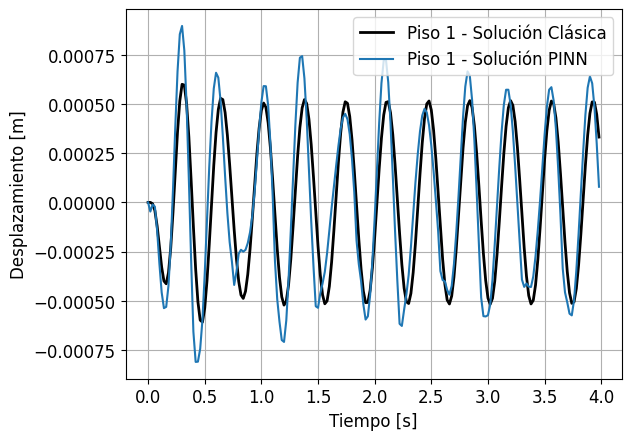

Error comparativo Energía total: 84.88%
Error comp. Desplazamiento: 56.69%
Error comp. Velocidad: 144.83%
imagen de energía guardado


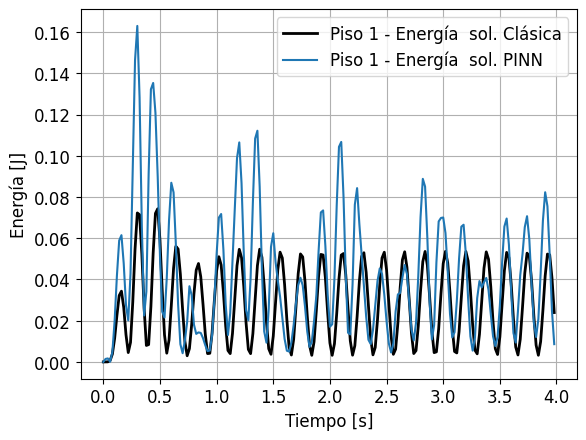

Piso 2: MAE = 3.198197e-04 m


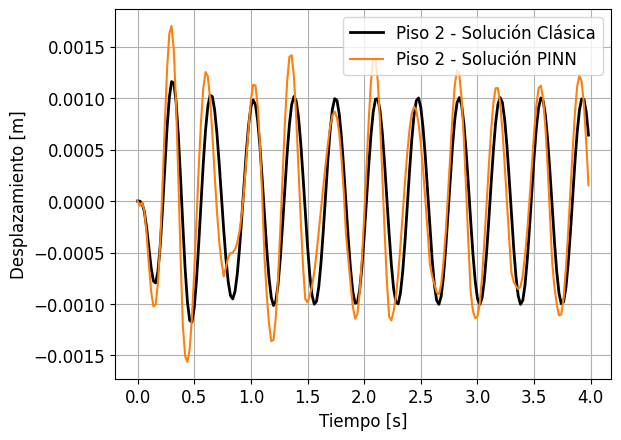

Error comparativo Energía total: 77.72%
Error comp. Desplazamiento: 54.32%
Error comp. Velocidad: 108.35%
imagen de energía guardado


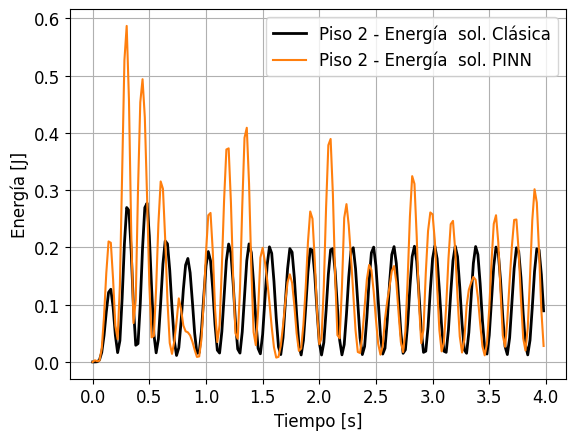

Piso 3: MAE = 4.283318e-04 m


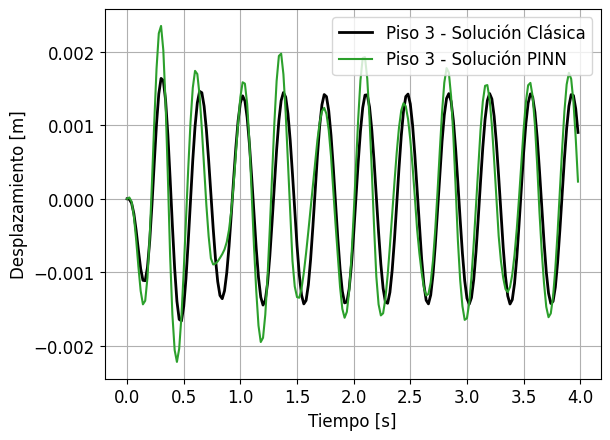

Error comparativo Energía total: 71.88%
Error comp. Desplazamiento: 50.86%
Error comp. Velocidad: 92.94%
imagen de energía guardado


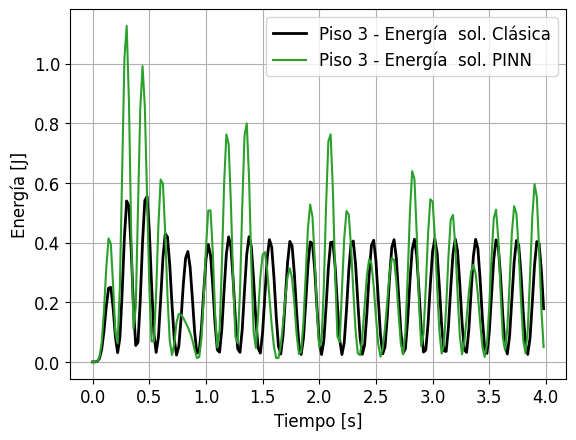

Piso 4: MAE = 4.843767e-04 m


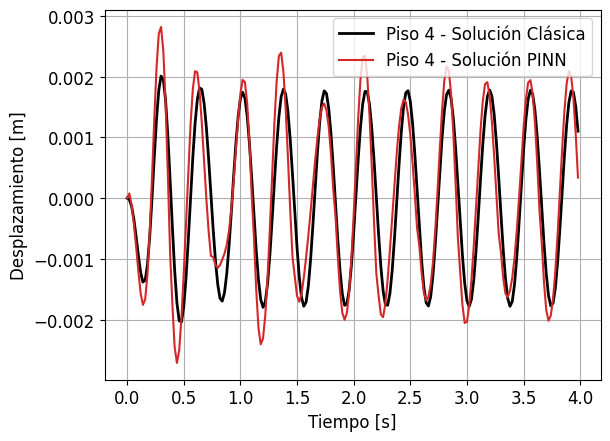

Error comparativo Energía total: 65.76%
Error comp. Desplazamiento: 46.34%
Error comp. Velocidad: 87.13%
imagen de energía guardado


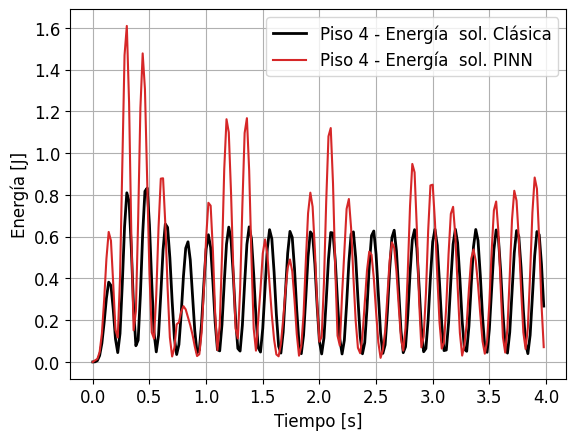

MAE Global: 3.510199e-04 m

Generando gráficos de momentos...


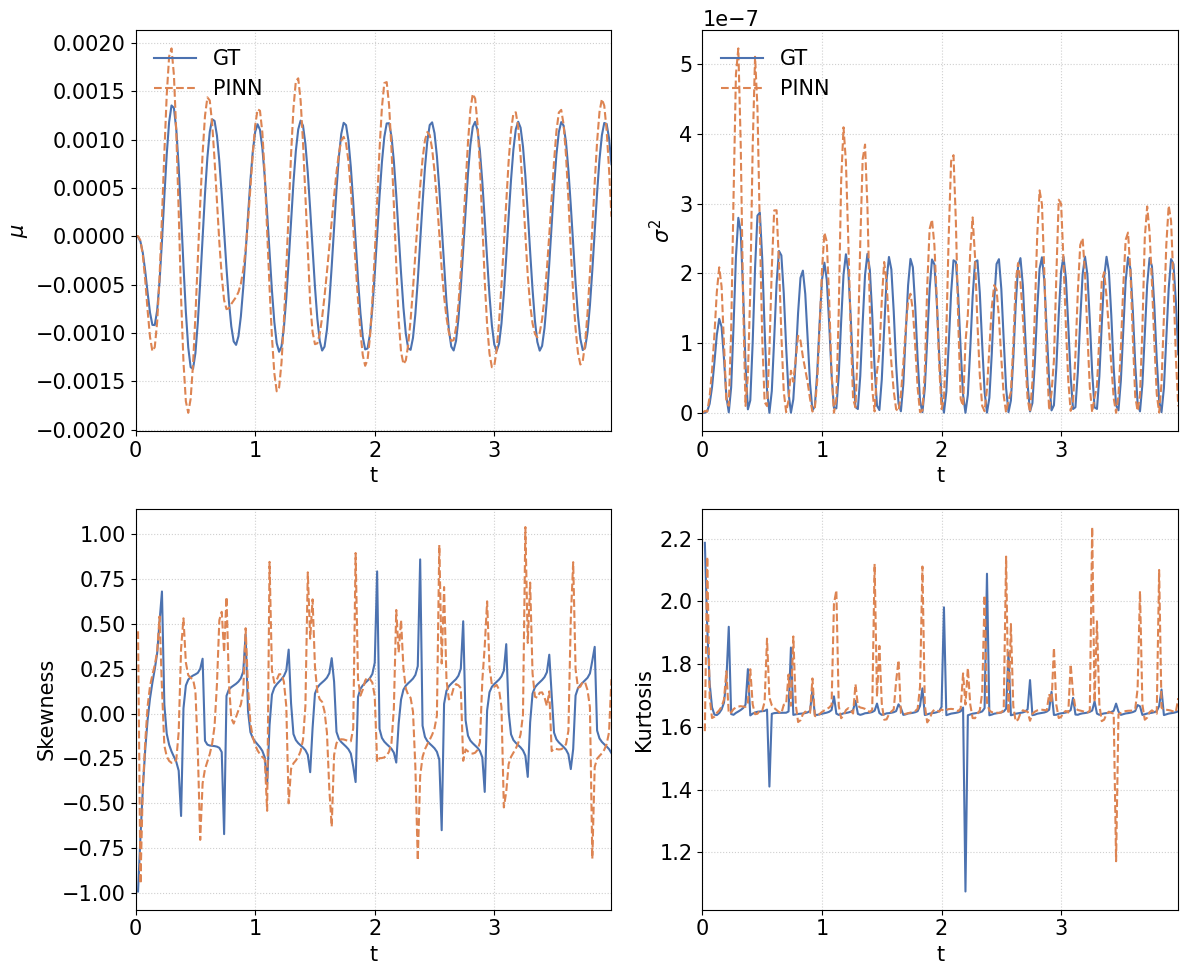


Generando gráficos de FFT...
Peaks de FFT encontrados @: [2.75 4.   5.5 ]


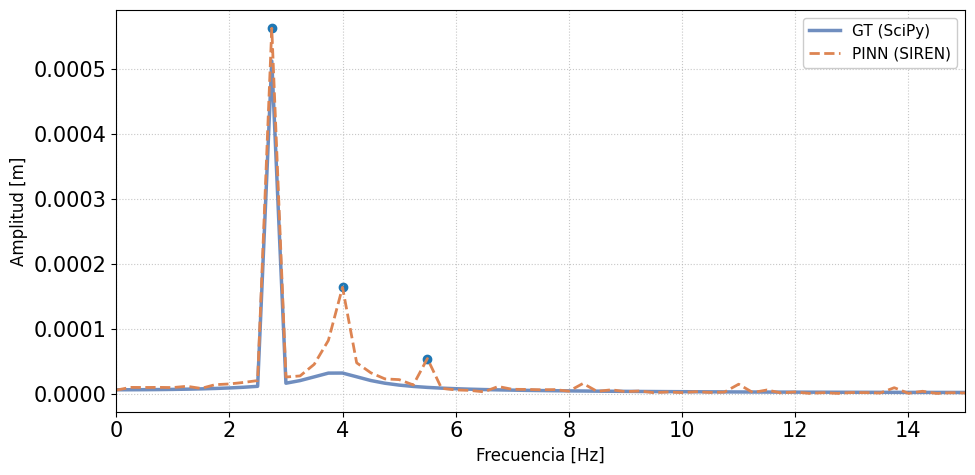

Peaks de FFT encontrados @: [2.75 4.   5.5 ]


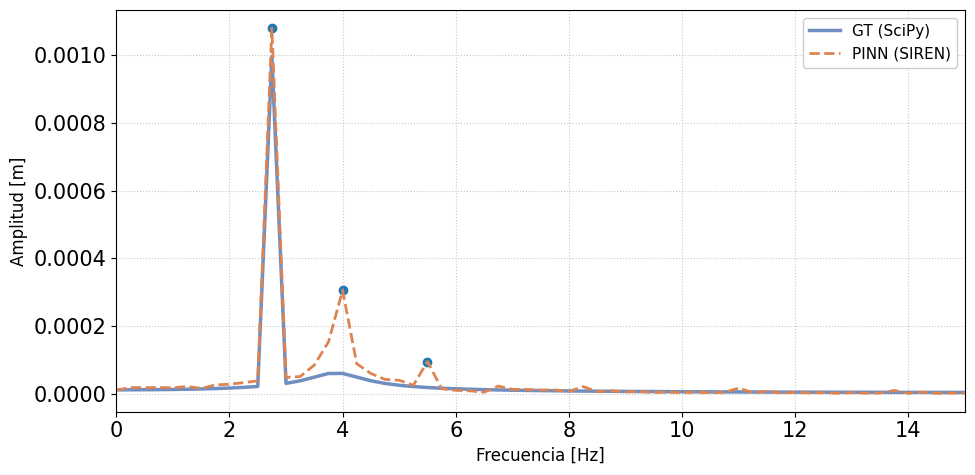

Peaks de FFT encontrados @: [2.75 4.   5.5  6.75]


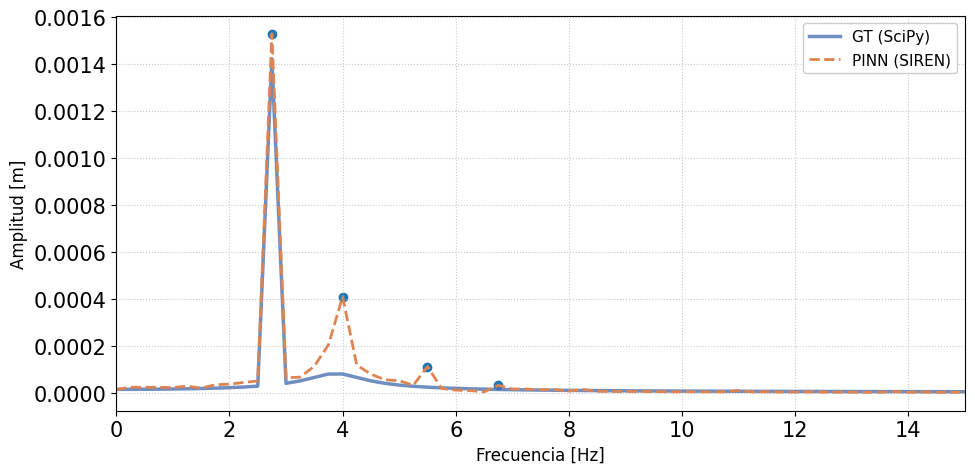

Peaks de FFT encontrados @: [1.25 2.75 4.   5.5  6.75]


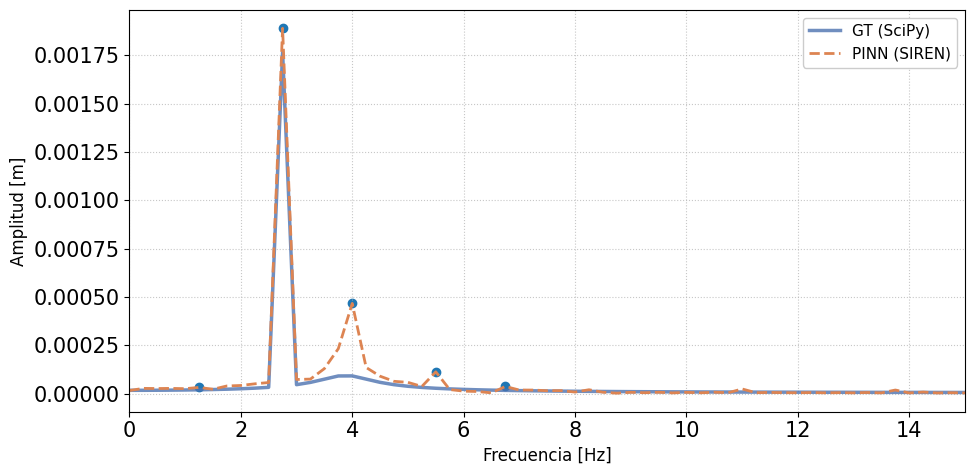

In [49]:
plt.rcParams.update({'font.size': 12})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

RUTA_SAVE_MODELS = "D:/Documentos/USM/Proyecto fis computacional/Avance 2/modelo_siren_4dof.pth"
n_dof = 4
dim_entrada = 3 + 2 * n_dof # 11 dimensiones

#Carga del modelo entrenado
modelo_siren = AutoregressivePINN_SIREN(dim_entrada, n_dof, hidden_features=128, omega_0=18.26129).to(device)
modelo_siren.load_state_dict(torch.load(RUTA_SAVE_MODELS))
modelo_siren.eval()


omega_test = 5.5 * np.pi
m_val, k_val = 80.0, 400000.0
t_step_max = 0.02

# 3.1 Evaluar modelo SIREN
print("\n--- Evaluando Modelo SIREN ---")
time_siren, u_clasico, u_pinn, v_clasico, v_pinn, metrics = evaluar_y_cuantificar_pinn(
    modelo_siren, n_dof, omega_test, m_val, k_val, tiempo_total=4, t_step_max=t_step_max)




for piso, mae in enumerate(metrics["maes_pisos"]):
    print(f"Piso {piso+1}: MAE = {mae:.6e} m")
    plt.plot(time_siren, u_clasico[piso], label=f'Piso {piso+1} - Solución Clásica', color='black', linewidth=2)
    plt.plot(time_siren, u_pinn[piso], label=f'Piso {piso+1} - Solución PINN', color=f'C{piso}', linewidth=1.5)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Desplazamiento [m]')
    plt.grid()
    plt.legend()
    # if save_plots:
    #     plt.savefig(RUTA_PLOTS + f"/test finales/MODELO FINAL_time{t}_seg_freq{omega_hz}_{piso+1}.png", dpi=400, bbox_inches="tight")
    plt.show()

    Ekin_clasico = 0.5*m_val*v_clasico[piso]**2
    Ekin_pinn = 0.5*m_val *v_pinn[piso]**2
    E_k_clasico = 0.5*k_val * u_clasico[piso]**2  #Energía elástica
    E_k_pinn = 0.5*k_val * u_pinn[piso]**2

    E_neto_clasico = E_k_clasico + Ekin_clasico
    E_neto_pinn = E_k_pinn + Ekin_pinn

    Error_comparativo = np.linalg.norm(E_neto_clasico - E_neto_pinn)/np.linalg.norm(E_neto_clasico)
    print(f"Error comparativo Energía total: {Error_comparativo*100:.2f}%")

    print(f"Error comp. Desplazamiento: {np.linalg.norm(u_clasico[piso] - u_pinn[piso])/np.linalg.norm(u_clasico[piso])*100:.2f}%")
    print(f"Error comp. Velocidad: {np.linalg.norm(v_clasico[piso] - v_pinn[piso])/np.linalg.norm(v_clasico[piso])*100:.2f}%")

    plt.plot(time_siren, E_neto_clasico, label=f'Piso {piso+1} - Energía  sol. Clásica', color='black', linewidth=2)
    plt.plot(time_siren, E_neto_pinn, label=f'Piso {piso+1} - Energía  sol. PINN', color=f'C{piso}', linewidth=1.5)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Energía [J]')
    plt.grid()
    plt.legend()
    plt.savefig(f"Energía piso {piso+1}.png", dpi=300, bbox_inches='tight')
    print(f"imagen de energía guardado")
    plt.show()



print(f"MAE Global: {metrics['mae_global']:.6e} m")
print("\nGenerando gráficos de momentos...")
analizar_momentos_estadisticos(time_siren, u_clasico, u_pinn,
                               guardar_plot=False, ruta_guardado="momentos_SIREN.png")
print("\nGenerando gráficos de FFT...")

for piso in (1,2,3,4):
    analizar_espectro_fft(time_siren, u_clasico, u_pinn, piso=piso-1, f_max=15.0,
                      guardar_plot=False, ruta_guardado=f"fft_SIREN_piso_{piso}.png")




##Grraficado de Error comparativo vs $\omega_{fuerza}$

Piso 1 -> MAE: 6.491503e-04 m
Piso 2 -> MAE: 5.344864e-04 m
Piso 3 -> MAE: 6.364440e-04 m
Piso 4 -> MAE: 1.118109e-03 m
----------------------------------------------------------------
MAE GLOBAL DEL EDIFICIO: 7.345474e-04 m

Piso 1 -> MAE: 6.542524e-04 m
Piso 2 -> MAE: 9.667449e-04 m
Piso 3 -> MAE: 8.640444e-04 m
Piso 4 -> MAE: 9.139243e-04 m
----------------------------------------------------------------
MAE GLOBAL DEL EDIFICIO: 8.497415e-04 m

Piso 1 -> MAE: 6.813787e-04 m
Piso 2 -> MAE: 6.765479e-04 m
Piso 3 -> MAE: 1.104944e-03 m
Piso 4 -> MAE: 1.188737e-03 m
----------------------------------------------------------------
MAE GLOBAL DEL EDIFICIO: 9.129020e-04 m

Piso 1 -> MAE: 7.041386e-04 m
Piso 2 -> MAE: 8.749480e-04 m
Piso 3 -> MAE: 1.345181e-03 m
Piso 4 -> MAE: 1.632735e-03 m
----------------------------------------------------------------
MAE GLOBAL DEL EDIFICIO: 1.139251e-03 m

Piso 1 -> MAE: 8.519840e-04 m
Piso 2 -> MAE: 1.195351e-03 m
Piso 3 -> MAE: 1.438531e-03 m
Piso 4

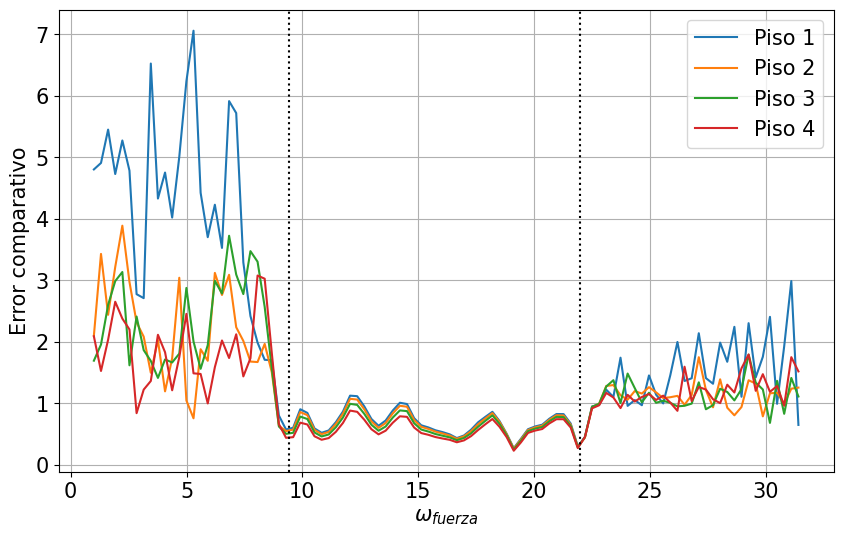

In [64]:
omega_range = np.linspace(1,10*np.pi,100)
ERROR_COMP_LIST=[]
for omega in omega_range:
    time_siren, u_clasico, u_pinn, v_clasico, v_pinn, metrics = evaluar_y_cuantificar_pinn(
    modelo_siren, n_dof, float(omega), m_val, k_val, tiempo_total=4, t_step_max=t_step_max)

    lista_pisos = []
    for piso, mae in enumerate(metrics["maes_pisos"]):
        # print(f"Piso {piso+1}: MAE = {mae:.6e} m")
        Error_comparativo = np.linalg.norm(u_clasico[piso] - u_pinn[piso])/np.linalg.norm(u_clasico[piso])
        lista_pisos.append(Error_comparativo)
    ERROR_COMP_LIST.append(lista_pisos)

ERROR_COMP_LIST = np.array(ERROR_COMP_LIST)

plt.figure(figsize=(10,6))
for i in range(4):
    plt.plot(omega_range, ERROR_COMP_LIST[:,i], label=f'Piso {i+1}',color=f'C{i}')
plt.grid()
plt.xlabel("$\omega_{fuerza}$")
plt.ylabel("Error comparativo")
plt.axvline(3*np.pi, color="black", linestyle=":", label="3$\pi$")
plt.axvline(7*np.pi, color="black", linestyle=":", label="7$\pi$")
plt.legend()
plt.savefig("ErrorVsOmegafuerza.png", dpi=300, bbox_inches='tight')
plt.show()

